In [1]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 🔎 Étape 3 : Analyse Exploratoire des Données (EDA) (Squelette Étudiant)

Cette étape correspond au troisième chapitre du cours. L'objectif est d'explorer et de résumer les propriétés statistiques fondamentales de vos données et de réaliser du **Feature Engineering** pour enrichir vos modèles.

### 1. Préparation de l'environnement

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))


print("Librairies importées pour l'EDA !")

Librairies importées pour l'EDA !


### 2. Chargement des données nettoyées

In [3]:
df = pd.read_csv('../data/processed/cleaned_data_sample.csv')

df.head()

,Company,TypeName,Inches,Ram,OpSys,Price,Res_Width,Res_Height,Is_IPS,Cpu_Gamme,...,has_ssd,has_hdd,has_flash,has_hybrid,total_memory_gb,gpu_brand,has_intel_gpu,has_nvidia_gpu,has_amd_gpu,weight_kg
0,Apple,Ultrabook,13.3,8,macOS,71378.6832,2560,1600,1,Intel Core i5,...,1,0,0,0,128.0,Intel,1,0,0,1.37
1,Apple,Ultrabook,13.3,8,macOS,47895.5232,1440,900,0,Intel Core i5,...,0,0,1,0,128.0,Intel,1,0,0,1.34
2,HP,Notebook,15.6,8,No OS,30636.0000,1920,1080,0,Intel Core i5,...,1,0,0,0,256.0,Intel,1,0,0,1.86
3,Apple,Ultrabook,15.4,16,macOS,135195.3360,2880,1800,1,Intel Core i7,...,1,0,0,0,512.0,AMD,0,0,1,1.83
4,Apple,Ultrabook,13.3,8,macOS,96095.8080,2560,1600,1,Intel Core i5,...,1,0,0,0,256.0,Intel,1,0,0,1.37


### 3. Statistiques Descriptives

**À COMPLÉTER PAR L'ÉTUDIANT :**
Générez les résumés statistiques globaux et par groupes/catégories de votre jeu de données.

In [4]:
# TODO: Utiliser df.describe() et des agrégationsgroupby()
df.describe()

# Résumé des variables numériques (Price, Ram, Weight, Cpu_Frequence_GHz, etc.)
print("--- RÉSUMÉ STATISTIQUE DES VARIABLES NUMÉRIQUES ---")
display(df.describe().round(2))

# Résumé des variables textuelles/catégorielles (OpSys, Cpu_Gamme, Gpu_Constructeur)
print("\n--- RÉSUMÉ DES VARIABLES CATÉGORIELLES ---")
display(df.describe(include=['object', 'category']))

--- RÉSUMÉ STATISTIQUE DES VARIABLES NUMÉRIQUES ---


,Inches,Ram,Price,Res_Width,Res_Height,Is_IPS,Cpu_Frequence_GHz,has_ssd,has_hdd,has_flash,has_hybrid,total_memory_gb,has_intel_gpu,has_nvidia_gpu,has_amd_gpu,weight_kg
count,1272.00,1272.00,1272.00,1272.00,1272.00,1272.00,1272.00,1272.00,1272.00,1272.00,1272.00,1272.00,1272.00,1272.00,1272.00,1272.00
mean,15.13,8.47,59961.10,1894.20,1070.53,0.28,2.30,0.65,0.44,0.06,0.01,621.32,0.55,0.31,0.14,2.08
std,1.95,5.56,37346.46,494.39,284.51,0.45,0.51,0.48,0.50,0.23,0.10,481.34,0.50,0.46,0.35,0.81
min,10.10,2.00,9270.72,1366.00,768.00,0.00,0.90,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,14.00,4.00,31914.72,1600.00,900.00,0.00,2.00,0.00,0.00,0.00,0.00,256.00,0.00,0.00,0.00,1.50
50%,15.60,8.00,52107.84,1920.00,1080.00,0.00,2.50,1.00,0.00,0.00,0.00,500.00,1.00,0.00,0.00,2.04
75%,15.60,8.00,79346.84,1920.00,1080.00,1.00,2.70,1.00,1.00,0.00,0.00,1024.00,1.00,1.00,0.00,2.32
max,35.60,64.00,324954.72,3840.00,2160.00,1.00,3.60,1.00,1.00,1.00,1.00,2560.00,1.00,1.00,1.00,11.10



--- RÉSUMÉ DES VARIABLES CATÉGORIELLES ---


,Company,TypeName,OpSys,Cpu_Gamme,gpu_brand
count,1272,1272,1272,1272,1272
unique,19,6,9,40,4
top,Lenovo,Notebook,Windows 10,Intel Core i7,Intel
freq,290,710,1046,515,702


In [5]:
#profil  technique moyen par systeme d'exploitation
print("\n--- PROFIL MOYEN PAR SYSTÈME D'EXPLOITATION ---")
# On sélectionne les colonnes numériques clés à agréger
profil_opsys = df.groupby('OpSys')[['Price', 'Ram', 'weight_kg']].mean()
display(profil_opsys.round(2).sort_values(by='Price', ascending=False))


--- PROFIL MOYEN PAR SYSTÈME D'EXPLOITATION ---


,Price,Ram,weight_kg
OpSys,,,
macOS,93220.33,9.85,1.40
Windows 7,89864.78,7.91,1.87
Windows 10 S,68543.65,7.00,1.29
Mac OS X,67285.78,8.50,1.19
Windows 10,62222.90,8.83,2.11
Linux,32919.41,6.30,2.23
No OS,31892.93,6.54,2.19
Chrome OS,29495.02,4.81,1.40
Android,29250.72,4.00,0.69


### 5. Analyse des Corrélations

**À COMPLÉTER PAR L'ÉTUDIANT :**
Analysez la matrice des corrélations des caractéristiques numériques à l'aide de Pandas.

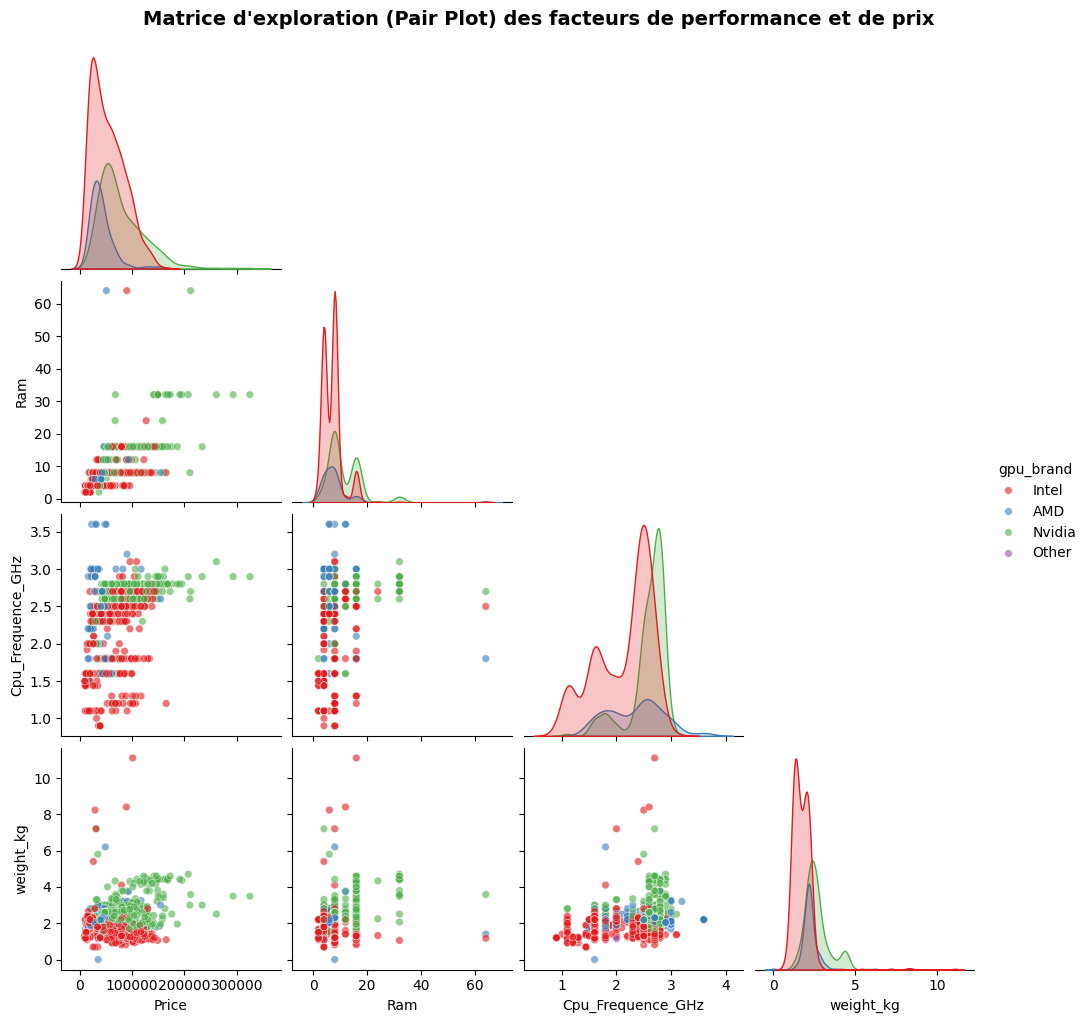

In [6]:
# TODO: Calculer les corrélations linéaires (Pearson ou Spearman)
# 1. On liste les colonnes qu'on veut analyser
colonnes_eda = ['Price', 'Ram', 'Cpu_Frequence_GHz' , 'weight_kg', 'gpu_brand']

# 2. On crée le pair plot (on filtre le DataFrame pour n'avoir que nos colonnes)
# corner=True permet de ne pas afficher la moitié supérieure qui est un miroir de la moitié inférieure
g = sns.pairplot(
    df[colonnes_eda], 
    hue='gpu_brand', 
    palette='Set1',
    corner=True,
    plot_kws={'alpha': 0.6, 's': 30} # Rend les points légèrement transparents pour mieux voir les superpositions
)

# 3. On ajoute un titre général
g.fig.suptitle("Matrice d'exploration (Pair Plot) des facteurs de performance et de prix", y=1.02, fontsize=14, fontweight='bold')

plt.show()

### 📊 Analyse 

## L'analyse du Prix (`Price`)

* **Description visuelle :** La courbe d'Intel (rouge) présente une forte concentration sur l'entrée de gamme, tandis que celle de Nvidia (verte) affiche une distribution beaucoup plus étalée vers les prix élevés, confirmant son positionnement premium..

* **Interprétation :** Le jeu de données est dominé par l'entrée de gamme, un segment saturé par les puces Intel. À l'inverse, les configurations Nvidia se positionnent presque exclusivement sur le segment haut de gamme (prix élevés).


##  Les relations avec la mémoire RAM

### 🔹 [Scatter Plot] RAM vs Price 
* **Description visuelle :** Les points ne sont pas éparpillés aléatoirement ; ils forment des 
valeurs strictes 
* **Interprétation :** Variable discrète progressant par paliers technologiques, la RAM dicte un effet de seuil sur le prix. Les configurations standards occupent l'entrée de gamme, tandis que les capacités de 32 Go et 64 Go sont exclusivement réservées aux tranches budgétaires supérieures.

### 📊 [Diagonale] Distribution de la RAM 
* **Description visuelle :** Le graphique affiche deux pics extrêmement pointus. Le premier pic, le plus massif et de couleur rouge (Intel), se situe pile sur la valeur 8 GB. Le second pic, plus bas et de couleur verte (Nvidia), est centré sur la valeur 16 GB.

* **Interprétation :** Le marché est fortement standardisé. La norme dominante pour les PC de bureau et les ultrabooks classiques (Intel) est de **8 GB de RAM**. À l'inverse, le standard pour les machines de performance ou de jeu (Nvidia) se situe à **16 GB de RAM**.


## 🚀 Les relations avec le processeur

### 🔹 [Scatter Plot] Fréquence CPU vs Price
* **Description visuelle :** Un nuage de points globalement incliné vers le haut. Le coin inférieur gauche (basse vitesse, bas prix) est exclusivement saturé par des points rouges (Intel). Plus on avance vers les prix élevés, plus les points grimpent en hauteur. Les points verts (Nvidia) forment un groupe compact sur les hautes fréquences (entre 2.5 et 3.0 GHz).

* **Interprétation :** Il existe une corrélation positive entre la vitesse d'horloge du processeur et le prix de vente. Les puces graphiques Nvidia ne sont jamais couplées à des processeurs d'entrée de gamme ; elles exigent des CPU à haute fréquence pour éviter les phénomènes de bridage .

### 🔹 [Scatter Plot] Fréquence CPU vs RAM 
* **Description visuelle :** Les points forment un effet de quadrillage. Sur la colonne de RAM à 4 GB, les fréquences CPU restent basses ou moyennes. Sur les colonnes à 16 GB et 32 GB, les points se concentrent majoritairement vers le haut de l'axe vertical.

* **Interprétation :** Les constructeurs conçoivent des configurations matérielles équilibrées. Une forte quantité de mémoire RAM est quasi systématiquement associée à un processeur rapide, créant une grappe de performance très visible pour le groupe Nvidia (Vert).

### 📊 [Diagonale] Distribution de la Fréquence CPU 
* **Description visuelle :** On observe deux cloches principales. La courbe rouge (Intel) a son sommet autour de 2.0 GHz, tandis que la courbe verte (Nvidia) affiche une forte concentration juste au-dessus de 2.5 GHz.

* **Interprétation :** Les PC portables à usage traditionnel (Intel) sont calibrés sur des fréquences modérées pour économiser l'énergie. Les PC orientés performance/gaming (Nvidia) embarquent des processeurs nativement plus véloces.

## ⚖️ Les relations avec la mobilité (`weight_kg`)

### 🔹 [Scatter Plot] Poids vs Price 
* **Description visuelle :** Le gros de la population forme un rectangle horizontal compact situé entre 1 kg et 3 kg, s'étendant sur toute la largeur des prix. Cependant, **plusieurs points s'échappent verticalement tout en haut**, atteignant des poids extrêmes compris entre 6 kg et 11 kg, tout en restant à des prix bas ou moyens.

* **Interprétation :** Le poids n'a aucune relation linéaire avec le prix. Un ordinateur ultra-premium peut être extrêmement léger (ultrabook). 
* **Alerte Qualité des Données :** Les points isolés situés au-dessus de 6 kg représentent des **valeurs aberrantes (outliers)**. Un ordinateur portable de 11 kg à bas prix correspond à une erreur de saisie ou à une autre informations mais cela on sait pas.

### 🔹 [Scatter Plot] Poids vs RAM 
* **Description visuelle :** Les points sont dispersés sans structure géométrique particulière. On remarque toutefois que nos anomalies de poids (> 6 kg) se situent toutes sur les colonnes de faible RAM (4 GB et 8 GB).
* **Interprétation :** Augmenter la mémoire RAM n'alourdit pas physiquement la machine. Le fait que les PC les plus lourds du fichier possèdent très peu de RAM confirme qu'il s'agit soit de bugs de saisie, soit de modèles industriels obsolètes.

### 🔹 [Scatter Plot] Poids vs Fréquence CPU 
* **Description visuelle :** Les points verts (Nvidia) se regroupent en un bloc très localisé : ils pèsent presque tous entre 2 et 4 kg et se situent sur des fréquences CPU élevées. Les points rouges (Intel) descendent quant à eux fréquemment sous la barre des 1.5 kg.

* **Interprétation :** C'est une contrainte physique d'ingénierie. L'alliance d'un processeur rapide et d'une carte graphique dédiée (Nvidia) dégage une chaleur importante. Pour refroidir le système, les constructeurs doivent intégrer des ventilateurs et des radiateurs en cuivre volumineux, ce qui augmente mécaniquement le poids de ces machines par rapport aux modèles Intel à puce graphique intégrée.

### 📊 [Diagonale] Distribution du Poids
* **Description visuelle :** Une courbe principale très pointue qui culmine aux alentours de 2 kg. La courbe rouge (Intel) chute rapidement après 2.5 kg, tandis que la courbe verte (Nvidia) dessine une seconde ondulation (une bosse secondaire) entre 2.5 kg et 4 kg.

* **Interprétation :** La norme physique pour un ordinateur portable moderne se situe autour de 2 kg. Intel domine le segment des poids plumes (les ultrabooks), alors que Nvidia crée une sous-population distincte de machines plus lourdes (les PC portables de jeu).

### 🚀 Conclusion 
### Les 3 moteurs du prix

* **La RAM (Facteur n°1) :** Le prix monte par marches d'escalier strictes (8 Go → 16 Go → 32 Go). Le très haut de gamme est verrouillé à partir de 32 Go.
* **Le GPU (La carte graphique) :** Il sépare le marché en deux segments. **Intel** = bureautique et bas coût. **Nvidia** = performance et prix élevé.
* **Le CPU (Le processeur) :** Plus la fréquence dépasse 2.5 GHz, plus le prix s'envole. Ces gros moteurs fonctionnent systématiquement en duo avec Nvidia.


### ⚖️ Le piège du Poids 
  1. **Les PC Gamers (Lourds & Chers) :** Ils pesent lourd (2,5 à 4 kg) à cause du système de refroidissement en cuivre obligatoire pour gérer la puissance brute.
  2. **Les Ultrabooks (Légers & Chers) :** Ils sont plumes (moins de 1,5 kg) mais coûtent une fortune en raison des matériaux de pointe (carbone, magnésium) requis pour les miniaturiser.
